In [1]:
import os
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.interpolate import CubicSpline
from scipy.optimize import curve_fit
from skimage.registration import phase_cross_correlation
from scipy.ndimage import gaussian_filter, gaussian_filter1d, shift, sobel
from scipy.fft import fft2, ifft2, fftfreq
from scipy.interpolate import interp1d

In [2]:
GLOBAL_SCALE = 65535.0
EPS = 1e-12

In [3]:
def to_unit(image):
    maxValue = np.iinfo(image.dtype).max
    image = image.astype(np.float32)
    image = image / maxValue
    return image

In [4]:
def read_all_tiff_files(folder_path):

    stacks = {}

    for filename in os.listdir(folder_path):
        if filename.lower().endswith((".tif", ".tiff")):
            path = os.path.join(folder_path, filename)

            try:
                dwell = int(os.path.splitext(filename)[0])

                with Image.open(path) as img:
                    pages = []
                    for i in range(img.n_frames):
                        img.seek(i)
                        pages.append(np.array(img))

                    stacks[dwell] = np.stack(pages)

            except Exception as e:
                print(f"Skipping {filename}: {e}")

    return stacks


def load_tiff_stack(path):
    img = Image.open(path)

    frames = []
    try:
        for i in range(img.n_frames):
            img.seek(i)
            frames.append(np.array(img))
    except AttributeError:
        # single image fallback
        frames = [np.array(img)]

    return np.stack(frames)

In [5]:
def normalize(img):
    return img.astype(np.float32) / GLOBAL_SCALE

In [6]:
def estimate_signal(stack):
    stack = stack.astype(np.float32)
    return np.median(stack, axis=0)
    
def estimate_noise(allTiffs):

    signals = {}
    noise_stats = {}

    for t, stack in allTiffs.items():

        signals[t] = estimate_signal(stack)

        stack = stack.astype(np.float32)
        S = signals[t][None, :, :]

        noise_raw = stack - S
        noise_raw = noise_raw - gaussian_filter(noise_raw, sigma=(0,3,3))

        sigmas = []
        corrs = []

        for i in range(noise_raw.shape[0]):   # loop over frames

            frame = noise_raw[i]

            sigmas.append(np.std(frame))
            corrs.append(estimate_corr_length(frame))

        noise_stats[t] = {
            "sigma": np.mean(sigmas),
            "corr": np.mean(corrs)
        }

    return signals, noise_stats

def compute_stats(allTiffs, signal_est):
    stats = {}

    for t, vid in allTiffs.items():
        residuals = vid - signal_est
        residuals = residuals.reshape(-1, *signal_est.shape)

        k2 = np.mean(residuals**2)
        k3 = np.mean(residuals**3)
        k4 = np.mean(residuals**4)
        corr = estimate_corr_length(residuals)

        stats[t] = (k2, k3, k4, corr)

    return stats

In [7]:
def estimate_corr_length(noise):

    f = np.fft.fft2(noise)
    psd = np.abs(f)**2

    fy = np.fft.fftfreq(noise.shape[0])
    fx = np.fft.fftfreq(noise.shape[1])
    FX, FY = np.meshgrid(fx, fy)

    r2 = FX**2 + FY**2

    psd = psd / (np.sum(psd) + 1e-12)

    # spectral centroid (KEY IDEA)
    spectral_width = np.sum(r2 * psd)

    # convert to correlation length
    corr_len = 1.0 / (spectral_width + 1e-8)

    return corr_len

In [8]:
def fit_model(stats):
    ts = np.array(sorted(stats.keys()))
    u = np.log(ts + 1e-8)

    k2 = np.array([stats[t][0] for t in ts])
    k3 = np.array([stats[t][1] for t in ts])
    k4 = np.array([stats[t][2] for t in ts])
    corr = np.array([stats[t][3] for t in ts])

    return {
        "k2": CubicSpline(u, np.log(k2 + 1e-8)),
        "k3": CubicSpline(u, k3),
        "k4": CubicSpline(u, k4),
        "corr": CubicSpline(u, np.log(corr + 1e-8)),
    }

def correlated_noise(shape, corr_len):

    z = np.random.randn(*shape)

    fy = fftfreq(shape[0])
    fx = fftfreq(shape[1])
    FX, FY = np.meshgrid(fx, fy)

    filt = np.exp(-(FX**2 + FY**2) * corr_len**2)

    z = np.real(ifft2(fft2(z) * filt))

    return (z - np.mean(z)) / (np.std(z) + EPS)

In [9]:
def build_model(allTiffs):

    signals, noise_stats = estimate_noise(allTiffs)

    ts = np.array(sorted(allTiffs.keys()), dtype=np.float32)

    sigma_vals = np.array([noise_stats[t]["sigma"] for t in ts])
    corr_vals  = np.array([noise_stats[t]["corr"] for t in ts])

    # Fit physically meaningful parameters

    # sigma(t)^2 ≈ a/t + b
    inv_t = 1 / ts

    w = ts
    A = np.polyfit(inv_t, sigma_vals**2, 1)
    a, b = A[0], A[1]

    # corr(t) ≈ ell0 * exp(-k t)
    log_corr = np.log(corr_vals + 1e-8)
    k, log_ell0 = np.polyfit(ts, log_corr, 1)

    model = {
        "a": a,
        "b": b,
        "ell0": np.exp(log_ell0),
        "k": -k
    }

    return model


In [10]:
def gaussian_field(shape, corr):

    z = np.random.randn(*shape)

    fy = np.fft.fftfreq(shape[0])
    fx = np.fft.fftfreq(shape[1])
    FX, FY = np.meshgrid(fx, fy)

    f2 = FX**2 + FY**2

    # IMPORTANT: keep corr as LENGTH SCALE (not spectral exponent)
    corr = max(corr, 1e-3)

    # stable Gaussian spectral filter (no explosion)
    filt = np.exp(-f2 * (corr**2))

    zf = np.fft.fft2(z) * filt
    z = np.real(np.fft.ifft2(zf))

    # enforce unit variance AFTER shaping
    z = z - np.mean(z)
    z = z / (np.std(z) + 1e-8)

    return z


def lognormal_field(shape, corr_len, strength=0.3):
    g = gaussian_field(shape, corr_len)
    v = np.exp(strength * g)
    return v / np.mean(v)

In [11]:
def eval_model(model, t):

    sigma = np.sqrt(model["a"] / t + model["b"])
    corr  = model["ell0"] * np.exp(-model["k"] *t)

    return sigma, corr
    
def generate_sem_noise(shape, t, model):

    sigma, corr = eval_model(model, t)

    g = gaussian_field(shape, corr)

    noise = sigma * g

    return noise

def generate_relative_noise(shape, t_high, t_target, model):

    sigma_h, corr_h = eval_model(model, t_high)
    sigma_t, corr_t = eval_model(model, t_target)
  
    sigma_add = max(0.0, sigma_t - sigma_h)
    
    g = gaussian_field(shape, corr_t)
    
    noise = sigma_add * g

    return noise
        

In [12]:
def generate_low_dwell_image(image_high, t_target, model):

    # convert input to model space
    signal = to_unit(image_high)

    # generate noise in model space
    noise = generate_sem_noise(signal.shape, t_target, model)
    output = signal + noise

    # CLIP to valid range
    output = np.clip(output, 0.0, 1.0)

    # convert back using original dtype
    dtype = image_high.dtype

    if np.issubdtype(dtype, np.integer):
        max_val = np.iinfo(dtype).max
        output = (output * max_val).astype(dtype)
    else:
        output = output.astype(dtype)

    return output

In [13]:
allTiffs = read_all_tiff_files('Noise_evaluation_dataset')
for t, stack in allTiffs.items():
    allTiffs[t] = allTiffs[t][:,:-80,:]

In [14]:
def normalize_stack(stack):

    stack = stack.astype(np.float32)

    # infer scale safely
    if stack.max() > 1.5:
        stack = stack / stack.max()  # safe fallback per-stack
    else:
        stack = np.clip(stack, 0, 1)

    return stack
def normalize_all_videos(trainingSet):
    normed = {}
    for t, stack in trainingSet.items():
        normed[t] = normalize_stack(stack)
    return normed

In [15]:
allTiffsNorm = normalize_all_videos(allTiffs)

In [16]:
testImage = load_tiff_stack('Li_Expulsion_1.tif')[5]

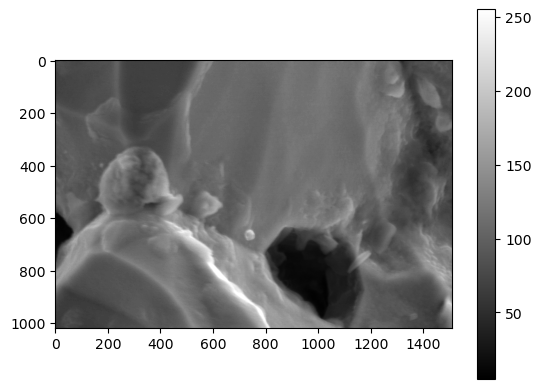

In [17]:
plt.imshow(testImage,cmap='grey')
plt.colorbar()
plt.show()

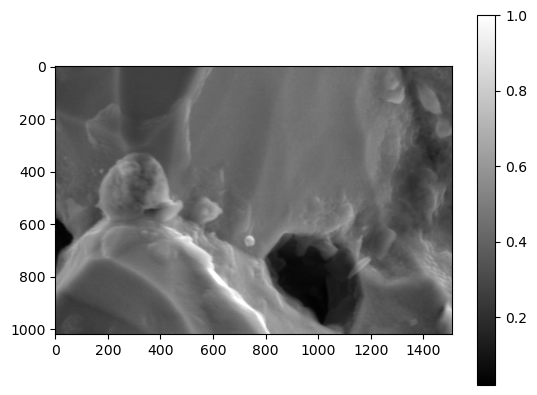

In [18]:
bla = to_unit(testImage)
plt.imshow(bla,cmap='grey')
plt.colorbar()
plt.show()

In [20]:
model = build_model(allTiffsNorm)

In [26]:
One = generate_low_dwell_image(testImage, 25, model)
Two = generate_low_dwell_image(testImage, 5000, model)
Three = generate_low_dwell_image(testImage, 20000, model)
Four = generate_low_dwell_image(testImage, 40000, model)

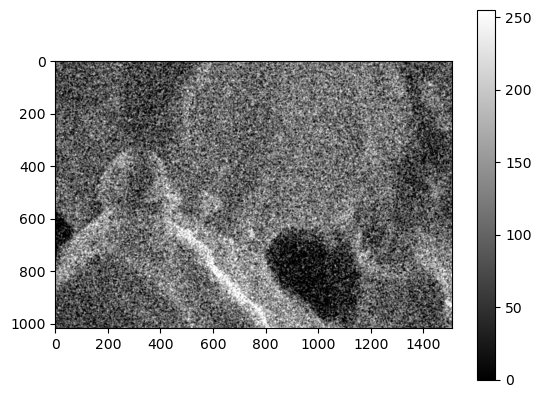

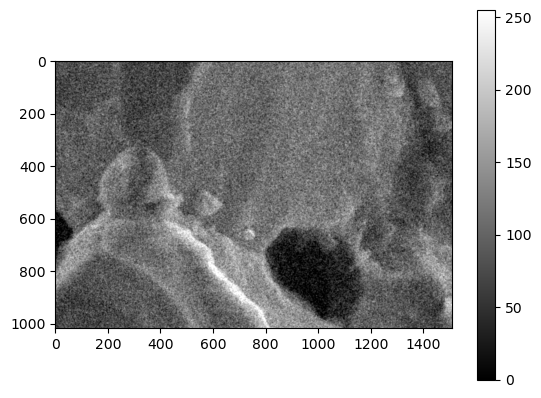

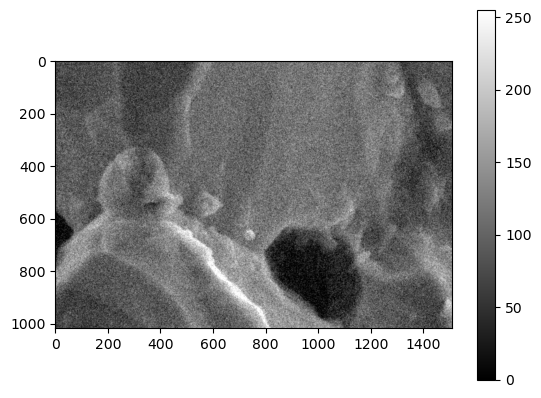

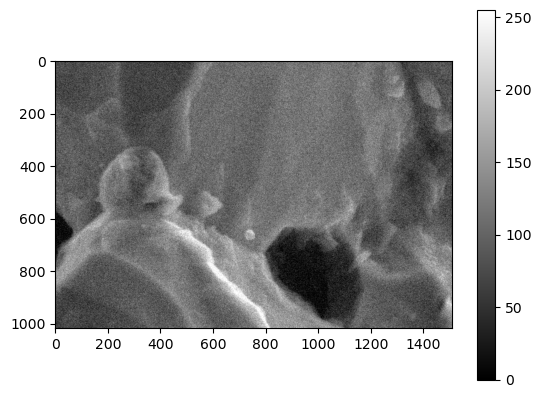

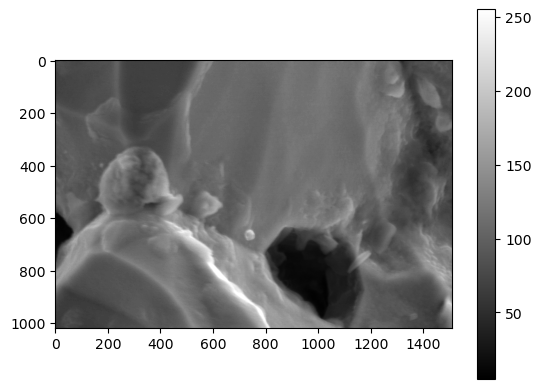

In [27]:
plt.imshow(One,cmap="grey")
plt.colorbar()
plt.show()
plt.imshow(Two,cmap="grey")
plt.colorbar()
plt.show()
plt.imshow(Three,cmap="grey")
plt.colorbar()
plt.show()
plt.imshow(Four,cmap='grey')
plt.colorbar()
plt.show()
plt.imshow(testImage,cmap='grey')
plt.colorbar()
plt.show()

In [30]:
def test_model(allTiffs, model, estimate_noise_func, eval_model_func, EPS=1e-8):

    # -------------------------
    # 1. empirical measurements
    # -------------------------
    signals, noise_stats = estimate_noise_func(allTiffs)

    ts = np.array(sorted(allTiffs.keys()), dtype=np.float32)

    sigma_emp = np.array([noise_stats[t]["sigma"] for t in ts])
    corr_emp  = np.array([noise_stats[t]["corr"] for t in ts])

    # -------------------------
    # 2. model predictions
    # -------------------------
    sigma_model = []
    corr_model = []

    for t in ts:
        s, c = eval_model_func(model, t)
        sigma_model.append(s)
        corr_model.append(c)

    sigma_model = np.array(sigma_model)
    corr_model  = np.array(corr_model)

    # -------------------------
    # 3. sanity prints
    # -------------------------
    print("\n===== SIGMA =====")
    print("empirical:", sigma_emp.min(), "→", sigma_emp.max())
    print("model    :", sigma_model.min(), "→", sigma_model.max())

    print("\n===== CORR =====")
    print("empirical:", corr_emp.min(), "→", corr_emp.max())
    print("model    :", corr_model.min(), "→", corr_model.max())

    # -------------------------
    # 4. σ(t) comparison
    # -------------------------
    plt.figure()
    plt.plot(ts, sigma_emp, 'o-', label="empirical σ")
    plt.plot(ts, sigma_model, 'x--', label="model σ")
    plt.xlabel("dwell time")
    plt.ylabel("sigma")
    plt.title("σ(t)")
    plt.legend()
    plt.show()

    # -------------------------
    # 5. CORE DIAGNOSTIC: σ² vs 1/t
    # -------------------------
    plt.figure()

    plt.plot(1/ts, sigma_emp**2 - np.min(sigma_emp**2), 'o', label="empirical (shifted)")
    plt.plot(1/ts, sigma_model**2 - np.min(sigma_model**2), 'x', label="model (shifted)")
    
    plt.xlabel("1 / t")
    plt.ylabel("sigma^2 (offset removed)")
    plt.title("Noise law check (bias removed)")
    plt.legend()
    plt.show()

    # -------------------------
    # 6. correlation comparison
    # -------------------------
    plt.figure()
    plt.plot(ts, corr_emp, 'o-', label="empirical corr")
    plt.plot(ts, corr_model, 'x--', label="model corr")
    plt.xlabel("dwell time")
    plt.ylabel("correlation length")
    plt.title("corr(t)")
    plt.legend()
    plt.show()


===== SIGMA =====
empirical: 0.022720557 → 0.13684273
model    : 0.07435830169482295 → 0.1530211020275445

===== CORR =====
empirical: 6.193263251731141 → 10.039082827734656
model    : 5.860468925303821 → 7.5413586811312046


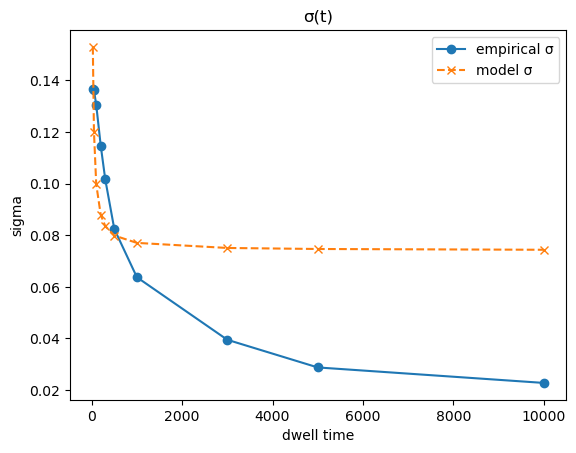

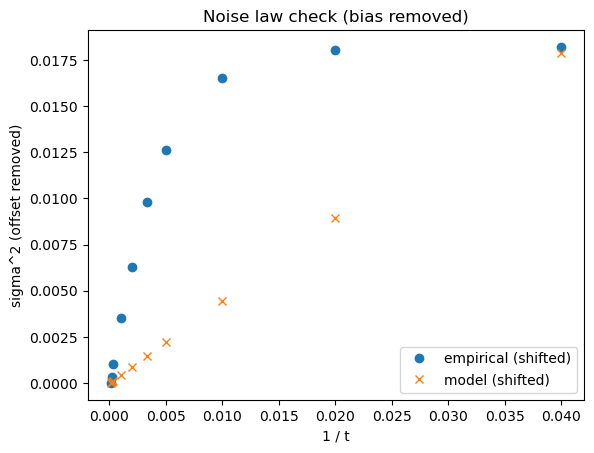

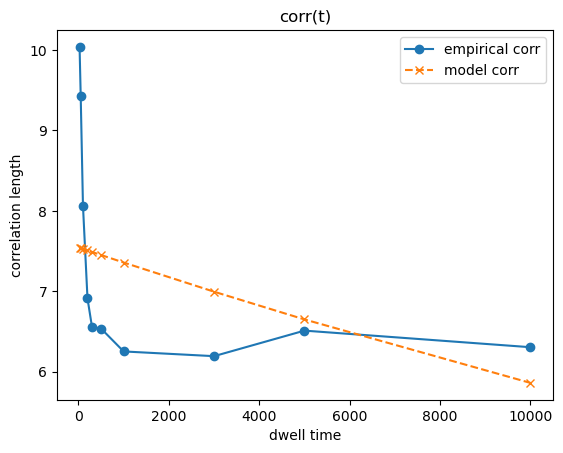

In [32]:
test_model(
    allTiffsNorm,
    model,
    estimate_noise_func=estimate_noise,
    eval_model_func=eval_model
)